# NN_09 — Logit como Estatística D3F

O problema dos notebooks anteriores: a saída sigmoid ∈ [0,1] é **limitada**, então o limiar D3F extrapolado para α=10⁻⁷ satura em 1.0 → PD=0.

**Solução**: usar o logit (ativação pré-sigmoid) `z = log(p/(1-p)) ∈ (-∞,+∞)` como estatística de teste.

Pela teoria de grandes desvios (Braca 2022), o logit converge para o LLR ótimo de N-P.
Por CLT com L=1024, é aproximadamente gaussiano sob H₀ → D3F funciona.

In [1]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from scipy.stats import norm
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')

notebook_dir       = Path.cwd()
project_root       = notebook_dir.parent
results_dir        = project_root / 'results'
data_dir           = results_dir / 'data'
models_dir         = results_dir / 'models'
vis_dir            = results_dir / 'visualizations'

ALPHA   = 1e-7
Q_INV   = norm.ppf(1 - ALPHA)   # ≈ 5.1993
SNR_BINS = [0, 5, 10, 15, 20, 25, 30]
print(f'\nα = {ALPHA:.0e}  →  Q⁻¹(1-α) = {Q_INV:.4f}')

I0000 00:00:1778470927.743836   33495 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778470927.793944   33495 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778470928.819244   33495 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

α = 1e-07  →  Q⁻¹(1-α) = 5.1993


In [2]:
# ==============================================================================
# 2. CARREGAR DATASET + EXTRAIR 4 FEATURES
# ==============================================================================
dataset_path = data_dir / 'dataset_cnn_yeq_0_30dB.h5'

with h5py.File(str(dataset_path), 'r') as f:
    Y_train = f['train/y_eq'][:].astype(np.float32)
    y_train = f['train/y'][:].astype(np.float32)
    snr_train = f['train/snr'][:]
    TAU_train = np.abs(f['train/tau_eq'][:]).astype(np.float32)

    Y_test  = f['test/y_eq'][:].astype(np.float32)
    y_test  = f['test/y'][:].astype(np.float32)
    snr_test = f['test/snr'][:]
    TAU_test = np.abs(f['test/tau_eq'][:]).astype(np.float32)

    L_FIXED = int(f.attrs['L_FIXED'])

def extract_features(Y, TAU, snr):
    h_est = np.abs(Y).mean(axis=1).astype(np.float32)
    E     = (Y ** 2).mean(axis=1).astype(np.float32)
    snr32 = snr.astype(np.float32)
    return np.stack([TAU, h_est, snr32, E], axis=1)

X4_train = extract_features(Y_train, TAU_train, snr_train)
X4_test  = extract_features(Y_test,  TAU_test,  snr_test)

# Normalizar com scaler salvo
scaler_path = models_dir / 'scaler_4feat_aligned.json'
with open(str(scaler_path)) as f:
    sc = json.load(f)
mean_ = np.array(sc['mean'], dtype=np.float32)
std_  = np.array(sc['std'],  dtype=np.float32)

X4_train_n = (X4_train - mean_) / std_
X4_test_n  = (X4_test  - mean_) / std_

# Reshape para CNN: (N, L, 1)
X_cnn_test = Y_test.reshape(-1, L_FIXED, 1)

print(f'4-feat test  : {X4_test_n.shape}  |  CNN test: {X_cnn_test.shape}')
print(f'SNR range    : {snr_test.min():.0f}–{snr_test.max():.0f} dB')

4-feat test  : (35000, 4)  |  CNN test: (35000, 1024, 1)
SNR range    : 0–30 dB


In [3]:
# ==============================================================================
# 3. CARREGAR MODELOS E CRIAR EXTRATORES DE LOGIT
# ==============================================================================

def make_logit_model(base_model, output_layer_name='P_H1', name='logit_model'):
    """Retorna modelo que produz o logit escalar (W·x+b antes do sigmoid)."""
    out_layer = base_model.get_layer(output_layer_name)
    kernel, bias = out_layer.get_weights()
    # Aplica Dense(1) sem ativação ao mesmo tensor que alimenta P_H1
    feat_tensor = out_layer.input  # KerasTensor (ex: 64-dim)
    logit_out = keras.layers.Dense(1, activation=None, use_bias=True,
                                   name=f'{name}_linear')(feat_tensor)
    model = keras.Model(inputs=base_model.input, outputs=logit_out, name=name)
    model.get_layer(f'{name}_linear').set_weights([kernel, bias])
    return model

# --- 4-feat DNN ---
model_4feat = keras.models.load_model(str(models_dir / 'model_dnn_4feat_aligned.keras'))
print('4-feat DNN carregado.')
logit_4feat_model = make_logit_model(model_4feat, name='logit_4feat')
print('  Logit 4-feat: saída shape =', logit_4feat_model.output.shape)

# --- 1D CNN ---
model_cnn = keras.models.load_model(str(models_dir / 'cnn1d_tag_auth_best.keras'))
print('\n1D CNN carregado.')
logit_cnn_model = make_logit_model(model_cnn, name='logit_cnn')
print('  Logit CNN: saída shape =', logit_cnn_model.output.shape)

I0000 00:00:1778470950.627056   33495 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


4-feat DNN carregado.
  Logit 4-feat: saída shape = (None, 1)

1D CNN carregado.
  Logit CNN: saída shape = (None, 1)


In [4]:
# ==============================================================================
# 4. PREDIÇÕES: SIGMOID E LOGIT
# ==============================================================================
BATCH = 512

# 4-feat DNN — sigmoid
p_4feat = model_4feat.predict(X4_test_n, batch_size=BATCH, verbose=0).flatten()

# 4-feat DNN — logit (pré-sigmoid)
if logit_4feat_model is not None:
    z_4feat = logit_4feat_model.predict(X4_test_n, batch_size=BATCH, verbose=0).flatten()
else:
    z_4feat = np.log(np.clip(p_4feat, 1e-7, 1-1e-7) / np.clip(1-p_4feat, 1e-7, 1-1e-7))

# 1D CNN — sigmoid
test_ds_cnn = tf.data.Dataset.from_tensor_slices(X_cnn_test).batch(BATCH).prefetch(tf.data.AUTOTUNE)
p_cnn = model_cnn.predict(test_ds_cnn, verbose=0).flatten()

# 1D CNN — logit
logit_ds = tf.data.Dataset.from_tensor_slices(X_cnn_test).batch(BATCH).prefetch(tf.data.AUTOTUNE)
z_cnn = logit_cnn_model.predict(logit_ds, verbose=0).flatten()

print(f'4-feat sigmoid  : min={p_4feat.min():.4f}  max={p_4feat.max():.4f}  AUC={roc_auc_score(y_test, p_4feat):.5f}')
print(f'4-feat logit    : min={z_4feat.min():.2f}  max={z_4feat.max():.2f}')
print(f'1D CNN sigmoid  : min={p_cnn.min():.4f}  max={p_cnn.max():.4f}  AUC={roc_auc_score(y_test, p_cnn):.5f}')
print(f'1D CNN logit    : min={z_cnn.min():.2f}  max={z_cnn.max():.2f}')

I0000 00:00:1778470951.734197   33592 service.cc:153] XLA service 0x7b4f0c02e960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778470951.734230   33592 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778470951.741314   33592 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1778470952.235680   33592 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778470952.261758   33592 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


I0000 00:00:1778470953.534710   33592 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778470953.689735   33594 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


4-feat sigmoid  : min=0.0000  max=1.0000  AUC=0.99979
4-feat logit    : min=-25.23  max=29.40
1D CNN sigmoid  : min=0.0000  max=1.0000  AUC=0.88471
1D CNN logit    : min=-44.79  max=20.32


In [5]:
# ==============================================================================
# 5. D3F — FUNÇÃO GENÉRICA
# ==============================================================================
def d3f_threshold(scores_h0, alpha=1e-7):
    """Ajusta gaussiana a H0 e extrapola limiar para alpha dado."""
    mu    = scores_h0.mean()
    sigma = scores_h0.std()
    thr   = mu + norm.ppf(1 - alpha) * sigma
    return float(thr), float(mu), float(sigma)

def eval_d3f(scores, y_true, snr, alpha=1e-7, clip=None):
    """Avalia PD vs SNR via D3F. clip=(lo,hi) para limitar threshold."""
    results = {}
    thresholds = {}
    for snr_db in SNR_BINS:
        mask_h0 = (snr >= snr_db - 2.5) & (snr < snr_db + 2.5) & (y_true == 0)
        mask_h1 = (snr >= snr_db - 2.5) & (snr < snr_db + 2.5) & (y_true == 1)
        if mask_h0.sum() < 30 or mask_h1.sum() < 10:
            results[snr_db] = None; thresholds[snr_db] = None; continue
        thr, mu, sigma = d3f_threshold(scores[mask_h0], alpha)
        if clip:
            thr = np.clip(thr, clip[0], clip[1])
        pd = float((scores[mask_h1] > thr).mean())
        results[snr_db] = pd
        thresholds[snr_db] = thr
    return results, thresholds

# Carregar resultados clássicos para referência
with open(str(data_dir / 'nn08_architecture_comparison.json')) as f:
    ref = json.load(f)
classical_pd = {int(k): v for k, v in ref['classical'].items()}
print('D3F implementado. Referência clássica carregada.')

D3F implementado. Referência clássica carregada.


In [6]:
# ==============================================================================
# 6. AVALIAR D3F: SIGMOID vs LOGIT PARA AMBOS OS MODELOS
# ==============================================================================

# 4-feat DNN
pd_4feat_sig, thr_4feat_sig = eval_d3f(p_4feat, y_test, snr_test, clip=(0, 1))
pd_4feat_log, thr_4feat_log = eval_d3f(z_4feat, y_test, snr_test)

# 1D CNN
pd_cnn_sig, thr_cnn_sig = eval_d3f(p_cnn, y_test, snr_test, clip=(0, 1))
pd_cnn_log, thr_cnn_log = eval_d3f(z_cnn, y_test, snr_test)

print('SNR  | Classical | 4feat-Sig | 4feat-Log | CNN-Sig | CNN-Log')
print('-' * 65)
for snr_db in SNR_BINS:
    cl  = classical_pd.get(snr_db, 0)
    fs  = pd_4feat_sig.get(snr_db) or 0
    fl  = pd_4feat_log.get(snr_db) or 0
    cs  = pd_cnn_sig.get(snr_db) or 0
    cl2 = pd_cnn_log.get(snr_db) or 0
    ts  = thr_4feat_log.get(snr_db)
    print(f'{snr_db:3d}  | {cl:8.4f}  | {fs:8.4f}  | {fl:8.4f}  | {cs:7.4f} | {cl2:7.4f}  (τ*={ts:.2f})')

SNR  | Classical | 4feat-Sig | 4feat-Log | CNN-Sig | CNN-Log
-----------------------------------------------------------------
  0  |   0.0810  |   0.8423  |   0.2968  |  0.0000 |  0.0000  (τ*=10.15)
  5  |   0.5874  |   0.9938  |   0.8208  |  0.0000 |  0.0003  (τ*=8.76)
 10  |   0.9987  |   1.0000  |   1.0000  |  0.0000 |  0.0013  (τ*=-3.04)
 15  |   1.0000  |   1.0000  |   1.0000  |  0.0000 |  0.0000  (τ*=-7.06)
 20  |   1.0000  |   1.0000  |   1.0000  |  0.9343 |  0.0000  (τ*=-8.21)
 25  |   1.0000  |   1.0000  |   1.0000  |  0.9928 |  0.1880  (τ*=-7.31)
 30  |   1.0000  |   1.0000  |   1.0000  |  0.9992 |  0.2213  (τ*=-8.84)


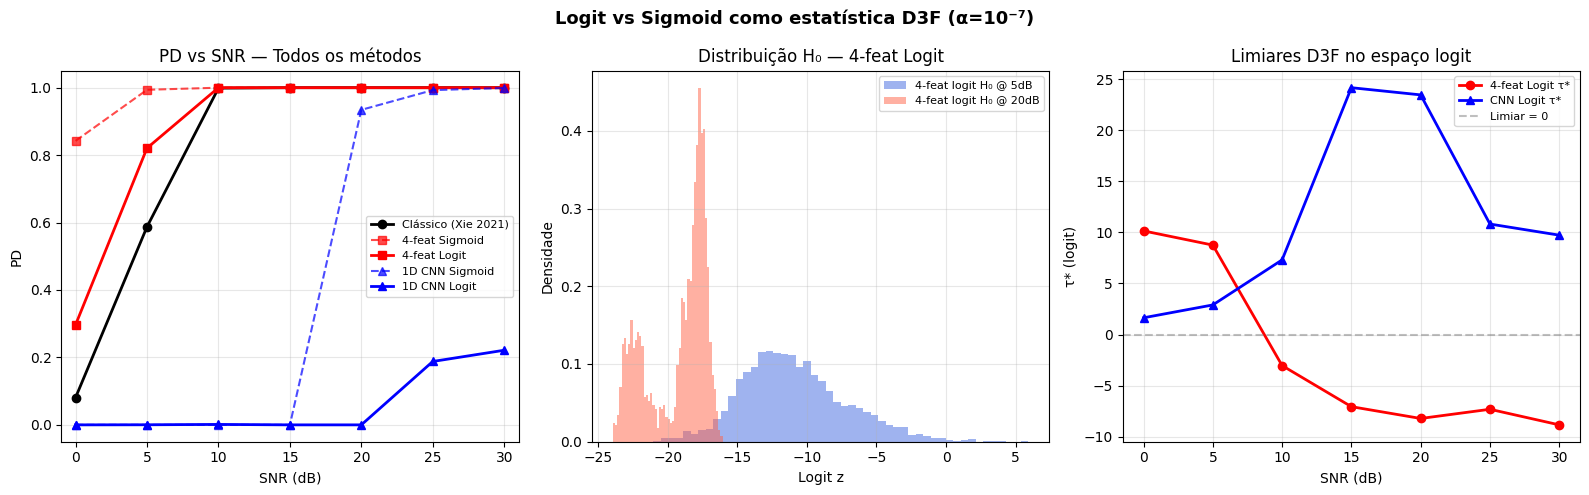

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN09_Logit_D3F_Comparison.png


In [7]:
# ==============================================================================
# 7. VISUALIZAÇÃO
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Logit vs Sigmoid como estatística D3F (α=10⁻⁷)', fontsize=13, fontweight='bold')

snr_vals = SNR_BINS

def get_vals(d, keys):
    return [d.get(k) or 0 for k in keys]

# --- Painel 1: Comparação geral ---
ax = axes[0]
ax.plot(snr_vals, get_vals(classical_pd, snr_vals), 'k-o', lw=2, label='Clássico (Xie 2021)')
ax.plot(snr_vals, get_vals(pd_4feat_sig, snr_vals), 'r--s', lw=1.5, alpha=0.7, label='4-feat Sigmoid')
ax.plot(snr_vals, get_vals(pd_4feat_log, snr_vals), 'r-s',  lw=2,   label='4-feat Logit')
ax.plot(snr_vals, get_vals(pd_cnn_sig,   snr_vals), 'b--^', lw=1.5, alpha=0.7, label='1D CNN Sigmoid')
ax.plot(snr_vals, get_vals(pd_cnn_log,   snr_vals), 'b-^',  lw=2,   label='1D CNN Logit')
ax.set(xlabel='SNR (dB)', ylabel='PD', title='PD vs SNR — Todos os métodos',
       ylim=(-0.05, 1.05), xlim=(-1, 31))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Painel 2: Distribuição dos escores sob H0 ---
ax = axes[1]
for snr_db, color in [(5, 'royalblue'), (20, 'tomato')]:
    mask_h0 = (snr_test >= snr_db - 2.5) & (snr_test < snr_db + 2.5) & (y_test == 0)
    if mask_h0.sum() > 50:
        ax.hist(z_4feat[mask_h0], bins=50, density=True, alpha=0.5,
                label=f'4-feat logit H₀ @ {snr_db}dB', color=color)
ax.set(xlabel='Logit z', ylabel='Densidade', title='Distribuição H₀ — 4-feat Logit')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Painel 3: Limiar D3F (logit) ---
ax = axes[2]
thr_log_vals = [thr_4feat_log.get(s) for s in snr_vals]
thr_cnn_log_vals = [thr_cnn_log.get(s) for s in snr_vals]
ax.plot(snr_vals, thr_log_vals,     'r-o', label='4-feat Logit τ*', lw=2)
ax.plot(snr_vals, thr_cnn_log_vals, 'b-^', label='CNN Logit τ*',    lw=2)
ax.axhline(0, color='gray', ls='--', alpha=0.5, label='Limiar = 0')
ax.set(xlabel='SNR (dB)', ylabel='τ* (logit)', title='Limiares D3F no espaço logit')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
vis_path = vis_dir / 'NN09_Logit_D3F_Comparison.png'
plt.savefig(str(vis_path), dpi=120)
plt.show()
print(f'Salvo → {vis_path}')

In [8]:
# ==============================================================================
# 8. SALVAR RESULTADOS
# ==============================================================================
results = {
    'alpha': ALPHA,
    'method': 'logit_d3f',
    'description': 'Pre-sigmoid logit used as D3F test statistic instead of sigmoid output',
    'classical':     {str(k): v for k, v in classical_pd.items()},
    '4feat_sigmoid': {str(k): pd_4feat_sig.get(k) for k in SNR_BINS},
    '4feat_logit':   {str(k): pd_4feat_log.get(k) for k in SNR_BINS},
    'cnn_sigmoid':   {str(k): pd_cnn_sig.get(k)   for k in SNR_BINS},
    'cnn_logit':     {str(k): pd_cnn_log.get(k)   for k in SNR_BINS},
    'thresholds': {
        '4feat_logit': {str(k): thr_4feat_log.get(k) for k in SNR_BINS},
        'cnn_logit':   {str(k): thr_cnn_log.get(k)   for k in SNR_BINS},
    }
}

out_path = data_dir / 'nn09_logit_d3f.json'
with open(str(out_path), 'w') as f:
    json.dump(results, f, indent=2)
print(f'Resultados salvos → {out_path}')

# Resumo
print('\n=== RESUMO ===')
print('4-feat DNN com logit melhorou?', any(pd_4feat_log.get(s, 0) > pd_4feat_sig.get(s, 0) for s in SNR_BINS))
print('1D CNN com logit melhorou?',      any(pd_cnn_log.get(s, 0)   > pd_cnn_sig.get(s, 0)   for s in SNR_BINS))
best_4feat = max((v for v in pd_4feat_log.values() if v is not None), default=0)
best_cnn   = max((v for v in pd_cnn_log.values()   if v is not None), default=0)
print(f'Melhor PD 4-feat logit: {best_4feat:.4f}')
print(f'Melhor PD CNN logit:    {best_cnn:.4f}')

Resultados salvos → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn09_logit_d3f.json

=== RESUMO ===
4-feat DNN com logit melhorou? False
1D CNN com logit melhorou? True
Melhor PD 4-feat logit: 1.0000
Melhor PD CNN logit:    0.2213
